In [1]:
import ROOT


Number of 4–5 MeV gammas: 224


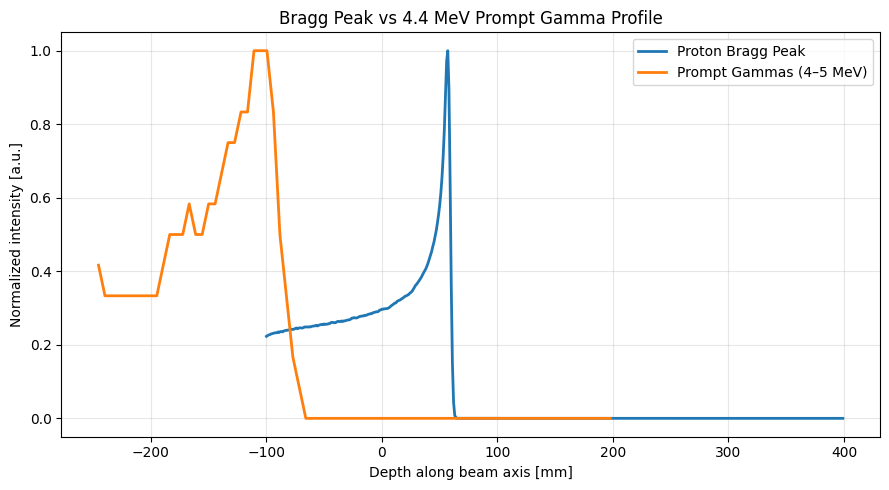

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# BRAGG PEAK PARAMETERS
# ==================================================
dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# GAMMA PARAMETERS (FROM YOUR WORKING CODE)
# ==================================================
TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11

E_MIN = 4.0   # MeV
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"].values * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING — IMPORTANT)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA DEPTH PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_centers = 0.5 * (gamma_edges[:-1] + gamma_edges[1:])

# Smooth + normalize
gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()

# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(
    bragg_z,
    bragg_norm,
    label="Proton Bragg Peak",
    linewidth=2
)

plt.plot(
    gamma_centers,
    gamma_norm,
    label="Prompt Gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs 4.4 MeV Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of 4–5 MeV gammas: 224


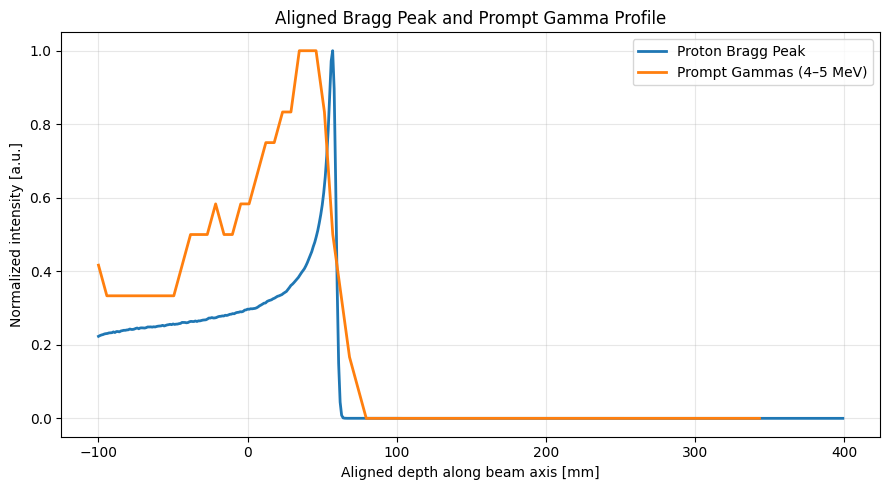

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# BRAGG PEAK PARAMETERS
# ==================================================
dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# GAMMA PARAMETERS (FROM YOUR WORKING CODE)
# ==================================================
TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11

E_MIN = 4.0   # MeV
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z_aligned = bragg_z - bragg_z.min()

bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()
# --------------------------------------------------
# Bragg peak position
# --------------------------------------------------
bragg_peak_idx = np.argmax(bragg_norm)
z_bragg_peak = bragg_z[bragg_peak_idx]

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING — IMPORTANT)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA DEPTH PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_z_aligned = gamma_centers - gamma_centers.min()

# Smooth + normalize
gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()
# --------------------------------------------------
# Gamma fall-off position (R50)
# --------------------------------------------------
gamma_peak_idx = np.argmax(gamma_norm)

gamma_post = gamma_norm[gamma_peak_idx:]
z_post = gamma_centers[gamma_peak_idx:]

R50_idx = np.where(gamma_post <= 0.5)[0][0]
z_gamma_R50 = z_post[R50_idx]

START_X = -100.0

bragg_z_aligned = bragg_z_aligned + START_X
gamma_z_aligned = gamma_z_aligned + START_X


# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(
    bragg_z_aligned,
    bragg_norm,
    label="Proton Bragg Peak",
    linewidth=2
)

plt.plot(
    gamma_z_aligned,
    gamma_norm,
    label="Prompt Gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Aligned depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Aligned Bragg Peak and Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Number of 4–5 MeV gammas: 224
===== RANGE RESULTS =====
Proton Bragg peak range : 57.00 mm
Proton R80 range        : 59.00 mm
Gamma R50 range         : 57.08 mm
Range difference ΔR     : -1.92 mm


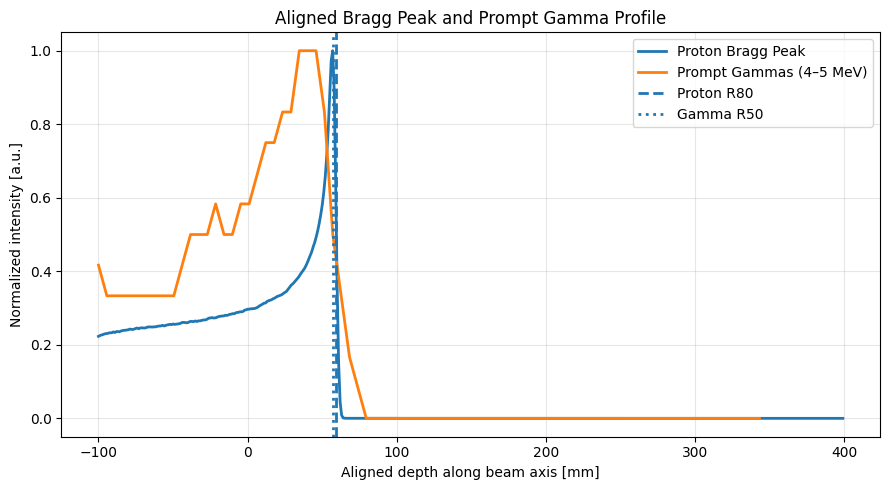

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# PARAMETERS
# ==================================================
dz_mm = 1.0
START_X = -100.0

TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11
E_MIN = 4.0
E_MAX = 5.0

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

# Physical depth
bragg_z = bragg_df["iZ"].values * dz_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# Align Bragg curve
bragg_z_aligned = bragg_z - bragg_z.min() + START_X

# Bragg peak and R80
idx_peak = np.argmax(bragg_norm)
R_peak = bragg_z_aligned[idx_peak]

post_peak_dose = bragg_norm[idx_peak:]
post_peak_z = bragg_z_aligned[idx_peak:]

idx_R80 = np.where(post_peak_dose <= 0.8)[0][0]
R80 = post_peak_z[idx_R80]

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)
    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_centers = 0.5 * (gamma_edges[:-1] + gamma_edges[1:])

gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()

# Align gamma curve
gamma_z_aligned = gamma_centers - gamma_centers.min() + START_X

# Gamma R50
gamma_peak_idx = np.argmax(gamma_norm)
gamma_post = gamma_norm[gamma_peak_idx:]
z_post = gamma_z_aligned[gamma_peak_idx:]

idx_R50 = np.where(gamma_post <= 0.5)[0][0]
R50_gamma = z_post[idx_R50]

# ==================================================
# RANGE DIFFERENCE
# ==================================================
delta_R = R50_gamma - R80

print("===== RANGE RESULTS =====")
print(f"Proton Bragg peak range : {R_peak:.2f} mm")
print(f"Proton R80 range        : {R80:.2f} mm")
print(f"Gamma R50 range         : {R50_gamma:.2f} mm")
print(f"Range difference ΔR     : {delta_R:.2f} mm")

# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(bragg_z_aligned, bragg_norm, label="Proton Bragg Peak", linewidth=2)
plt.plot(gamma_z_aligned, gamma_norm, label="Prompt Gammas (4–5 MeV)", linewidth=2)

plt.axvline(R80, linestyle="--", linewidth=2, label="Proton R80")
plt.axvline(R50_gamma, linestyle=":", linewidth=2, label="Gamma R50")

plt.xlabel("Aligned depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Aligned Bragg Peak and Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"

# ==================================================
# PARAMETERS
# ==================================================
dz_mm = 1.0
BRAGG_START_X = -300.0   # <-- Bragg axis starts at -300 mm

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX","iY","iZ","Edep_MeV","Edep2","Entries"]
)

# Physical depth
bragg_z = bragg_df["iZ"].values * dz_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# Align Bragg so it starts at -300 mm
bragg_z = bragg_z - bragg_z.min() + BRAGG_START_X

# ==================================================
# GAMMA BINNING (FROM YOUR WORKING CODE)
# ==================================================
# bins and centers ALREADY DEFINED FROM z_44
# bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
# centers = 0.5 * (bins[:-1] + bins[1:])

# --------------------------------------------------
# ALL GAMMAS
# --------------------------------------------------
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# --------------------------------------------------
# 4–5 MeV GAMMAS
# --------------------------------------------------
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

START_X = -300.0

# Shift gamma axis
centers_shifted = centers - centers.min() + START_X

# Shift Bragg axis
bragg_z_shifted = bragg_z - bragg_z.min() + START_X


# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(10,5))

plt.plot(
    bragg_z_shifted,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    centers_shifted,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    centers_shifted,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'z_all' is not defined

In [8]:
# ==================================================
# USE SAME Z-BINS AS 4.4 MeV CASE
# ==================================================
N_BINS = 80
SMOOTH_SIGMA = 2.0

# ---- Define PHYSICAL bins from 4.4 MeV gammas ----
bins = np.linspace(z_44.min(), z_44.max(), N_BINS)
centers = 0.5 * (bins[:-1] + bins[1:])

# ==================================================
# ALL GAMMAS PROFILE (FIXED)
# ==================================================
counts_all, _ = np.histogram(z_all, bins=bins)
counts_all = gaussian_filter1d(counts_all.astype(float), SMOOTH_SIGMA)
counts_all /= counts_all.max()

# ==================================================
# 4.4 MeV GAMMAS PROFILE (REFERENCE)
# ==================================================
counts_44, _ = np.histogram(z_44, bins=bins)
counts_44 = gaussian_filter1d(counts_44.astype(float), SMOOTH_SIGMA)
counts_44 /= counts_44.max()

# ==================================================
# PLOT GAMMAS ONLY (CORRECT AXIS)
# ==================================================
plt.figure(figsize=(9,5))

plt.plot(centers, counts_all, label="All gamma events", linewidth=2)
plt.plot(centers, counts_44, label="4–5 MeV gammas", linewidth=2)

plt.xlabel("Z position [mm]")
plt.ylabel("Normalized counts")
plt.title("Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


NameError: name 'z_44' is not defined

Gamma file columns:
Index(['Event_ID', 'Track_ID', 'Detector', 'Pos_X_mm', 'Pos_Y_mm', 'Pos_Z_mm',
       'Energy_MeV ', 'Deposited_MeV', 'Time_ns', 'True_Origin_X_mm',
       'True_Origin_Y_mm', 'True_Origin_Z_mm', 'Initial_Energy_MeV',
       'Detector_Num'],
      dtype='object')


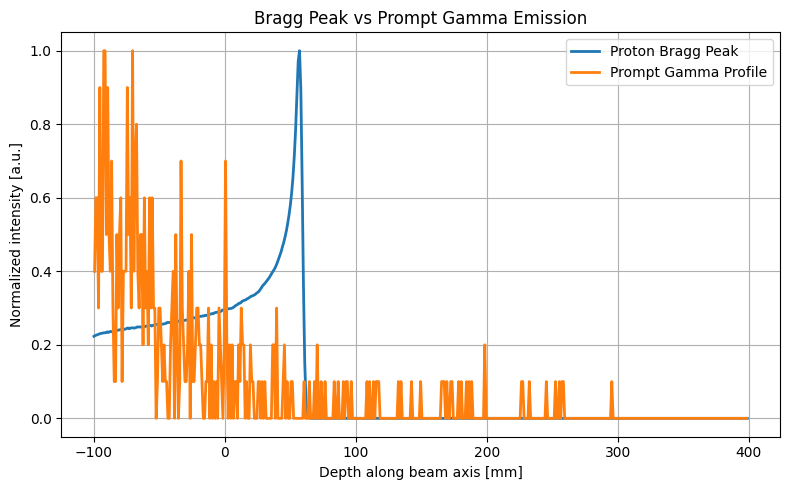

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"] * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"]
bragg_norm = bragg / bragg.max()

# ==================================================
# LOAD GAMMA HIT DATA (ROBUST)
# ==================================================
gamma_df = pd.read_csv(
    GAMMA_FILE,
    comment="#",
    sep=r",\s*",
    engine="python",
    on_bad_lines="skip"
)

print("Gamma file columns:")
print(gamma_df.columns)

# 🔴 CHANGE THIS IF YOUR COLUMN NAME IS DIFFERENT
gamma_z_hits = gamma_df["Pos_Z_mm"]   # or "Hit_Z_mm"

# ==================================================
# BUILD GAMMA PROFILE (HISTOGRAM)
# ==================================================
bins = np.linspace(bragg_z.min(), bragg_z.max(), len(bragg_z))

gamma_counts, bin_edges = np.histogram(gamma_z_hits, bins=bins)
gamma_z_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

gamma_norm = gamma_counts / gamma_counts.max()

# ==================================================
# PLOT COMPARISON
# ==================================================
plt.figure(figsize=(8, 5))

plt.plot(bragg_z, bragg_norm, label="Proton Bragg Peak", linewidth=2)
plt.plot(gamma_z_centers, gamma_norm, label="Prompt Gamma Profile", linewidth=2)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs Prompt Gamma Emission")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Number of 4–5 MeV gammas: 224


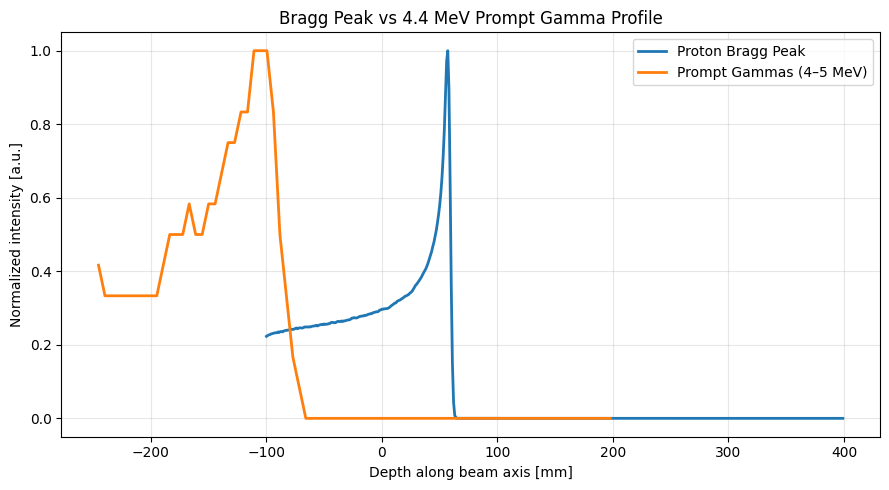

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ==================================================
# FILES
# ==================================================
BRAGG_FILE = "/home/meenakshi/bragg-peak/DATA_1/150.000000-MEV-100000-EVTS_protons.txt"
GAMMA_FILE = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

# ==================================================
# BRAGG PEAK PARAMETERS
# ==================================================
dz_mm = 1.0
x_offset_mm = -100.0

# ==================================================
# GAMMA PARAMETERS (FROM YOUR WORKING CODE)
# ==================================================
TRUE_Z_COL = 10
TRUE_ENERGY_COL = 11

E_MIN = 4.0   # MeV
E_MAX = 5.0   # MeV

N_BINS = 80
SMOOTH_SIGMA = 2.0

# ==================================================
# LOAD BRAGG PEAK DATA
# ==================================================
bragg_df = pd.read_csv(
    BRAGG_FILE,
    comment="#",
    header=None,
    names=["iX", "iY", "iZ", "Edep_MeV", "Edep2", "Entries"]
)

bragg_z = bragg_df["iZ"].values * dz_mm + x_offset_mm
bragg = bragg_df["Edep_MeV"].values
bragg_norm = bragg / bragg.max()

# ==================================================
# LOAD GAMMA DATA (MANUAL PARSING — IMPORTANT)
# ==================================================
z_vals = []

with open(GAMMA_FILE, "r") as f:
    lines = f.readlines()

for line in lines[1:]:
    parts = [p.strip() for p in line.split(",")]
    try:
        E = float(parts[TRUE_ENERGY_COL])
        Z = float(parts[TRUE_Z_COL])

        if E_MIN <= E <= E_MAX:
            z_vals.append(Z)

    except:
        continue

z_vals = np.array(z_vals)
print("Number of 4–5 MeV gammas:", len(z_vals))

# ==================================================
# BUILD GAMMA DEPTH PROFILE
# ==================================================
gamma_counts, gamma_edges = np.histogram(z_vals, bins=N_BINS)
gamma_centers = 0.5 * (gamma_edges[:-1] + gamma_edges[1:])

# Smooth + normalize
gamma_smooth = gaussian_filter1d(gamma_counts, sigma=SMOOTH_SIGMA)
gamma_norm = gamma_smooth / gamma_smooth.max()

# ==================================================
# OVERLAY PLOT
# ==================================================
plt.figure(figsize=(9, 5))

plt.plot(
    bragg_z,
    bragg_norm,
    label="Proton Bragg Peak",
    linewidth=2
)

plt.plot(
    gamma_centers,
    gamma_norm,
    label="Prompt Gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak vs 4.4 MeV Prompt Gamma Profile")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Gamma CSV
# -----------------------------
GAMMA_CSV = "/home/meenakshi/bragg-peak/build/detector_hits_100000.csv"

TRUE_ENERGY_COL = 11
TRUE_Z_COL = 10

E_MIN = 3.0
E_MAX = 5.0

N_BINS = 80
SMOOTH_SIGMA = 2.0

z_gamma = []

with open(GAMMA_CSV, "r") as f:
    next(f)
    for line in f:
        parts = [p.strip() for p in line.split(",")]
        try:
            E = float(parts[TRUE_ENERGY_COL])
            Z = float(parts[TRUE_Z_COL])
            if E_MIN <= E <= E_MAX:
                z_gamma.append(Z)
        except:
            continue

z_gamma = np.array(z_gamma)
print("Gamma events (3–5 MeV):", len(z_gamma))

counts_g, edges_g = np.histogram(z_gamma, bins=N_BINS)
centers_g = 0.5 * (edges_g[:-1] + edges_g[1:])
counts_g = gaussian_filter1d(counts_g, sigma=SMOOTH_SIGMA)
counts_g = counts_g /counts_g.max()


Gamma events (3–5 MeV): 337


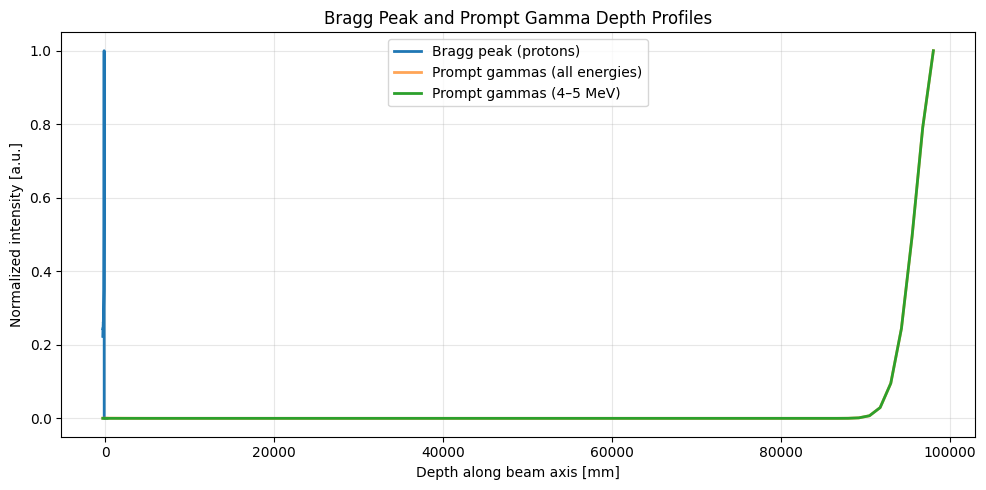

In [19]:
# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(10,5))

plt.plot(
    bragg_z_shifted,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    centers_shifted,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    centers_shifted,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)

# 🔴 THIS IS THE KEY LINE
plt.xlim(-300, 300)

plt.tight_layout()
plt.show()
# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(10,5))

plt.plot(
    bragg_z_shifted,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    centers_shifted,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    centers_shifted,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)

# 🔴 THIS IS THE KEY LINE
plt.xlim(-300, 300)

plt.tight_layout()
plt.show()


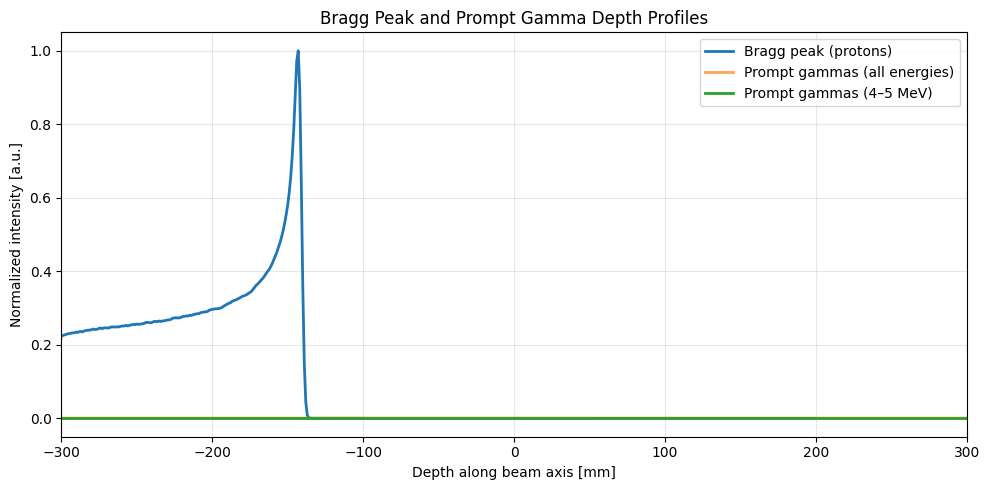

In [20]:
# ==================================================
# PLOT: BRAGG + GAMMAS
# ==================================================
plt.figure(figsize=(10,5))

plt.plot(
    bragg_z_shifted,
    bragg_norm,
    label="Bragg peak (protons)",
    linewidth=2
)

plt.plot(
    centers_shifted,
    counts_all,
    label="Prompt gammas (all energies)",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    centers_shifted,
    counts_44,
    label="Prompt gammas (4–5 MeV)",
    linewidth=2
)

plt.xlabel("Depth along beam axis [mm]")
plt.ylabel("Normalized intensity [a.u.]")
plt.title("Bragg Peak and Prompt Gamma Depth Profiles")
plt.legend()
plt.grid(alpha=0.3)

# 🔴 THIS IS THE KEY LINE
plt.xlim(-300, 300)

plt.tight_layout()
plt.show()
